# **🏦 Bank Customer Product Prediction (ML Models)**

**Goal:** predict whether a bank customer holds **more than one bank product** (`NumOfProducts > 1`) using only profile columns: credit score, country, gender, age, tenure and balance.


## **📚 What this notebook contains**
1. Import libraries and load data
2. Quick data check
3. Create the target + EDA
4. Prepare the data
5. Train multiple models (baseline → best)
6. Compare models
7. Tune the best model
8. Final evaluation and important features
9. Conclusion

## **1️⃣ Import libraries**

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

## **2️⃣ Load the data and take a first look**

In [2]:
import glob
files = glob.glob("/kaggle/input/datasets/srisyra02/bank-customer-churn-prediction/Customer-Churn-Records.csv", recursive=True) + glob.glob("Customer-Churn-Records.csv")
df = pd.read_csv(files[0])
print("Shape:", df.shape)
df.head()

Shape: (10000, 10)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
0,1,15574012,Chu,645,Spain,Male,44,8,113755.78,2
1,2,15592531,Bartlett,822,France,Male,50,7,0.00,2
2,3,15656148,Obinna,376,Germany,Female,29,4,115046.74,4
3,4,15792365,He,501,France,Male,44,4,142051.07,2
4,5,15592389,H?,684,France,Male,27,2,134603.88,1


In [3]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe().round(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RowNumber      10000 non-null  int64  
 1   CustomerId     10000 non-null  int64  
 2   Surname        10000 non-null  object 
 3   CreditScore    10000 non-null  int64  
 4   Geography      10000 non-null  object 
 5   Gender         10000 non-null  object 
 6   Age            10000 non-null  int64  
 7   Tenure         10000 non-null  int64  
 8   Balance        10000 non-null  float64
 9   NumOfProducts  10000 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 781.4+ KB

Missing values: 0
Duplicate rows: 0


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,5000.5,15690940.6,650.5,38.9,5.0,76485.9,1.5
std,2886.9,71936.2,96.7,10.5,2.9,62397.4,0.6
min,1.0,15565701.0,350.0,18.0,0.0,0.0,1.0
25%,2500.8,15628528.2,584.0,32.0,3.0,0.0,1.0
50%,5000.5,15690738.0,652.0,37.0,5.0,97198.5,1.0
75%,7500.2,15753233.8,718.0,44.0,7.0,127644.2,2.0
max,10000.0,15815690.0,850.0,92.0,10.0,250898.1,4.0


## **3️⃣ Create the target and explore the data**
`Multi_Product = 1` if the customer has 2 or more products, else `0`.

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Multi-product customers: 49.2%


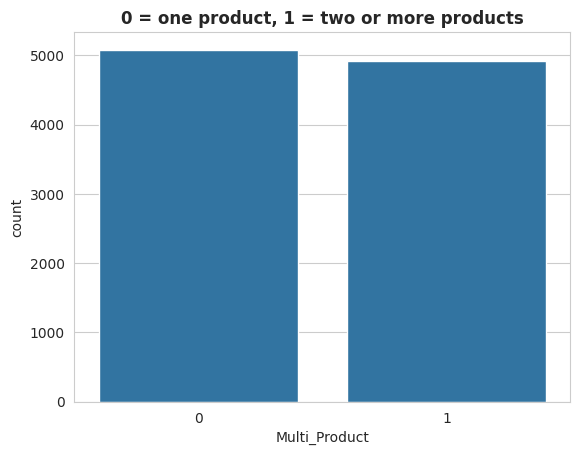

In [4]:
df["Multi_Product"] = (df["NumOfProducts"] > 1).astype(int)
print(df["NumOfProducts"].value_counts().sort_index())
print(f"\nMulti-product customers: {df['Multi_Product'].mean():.1%}")
sns.countplot(x="Multi_Product", data=df)
plt.title("0 = one product, 1 = two or more products",fontweight='bold'); plt.show()

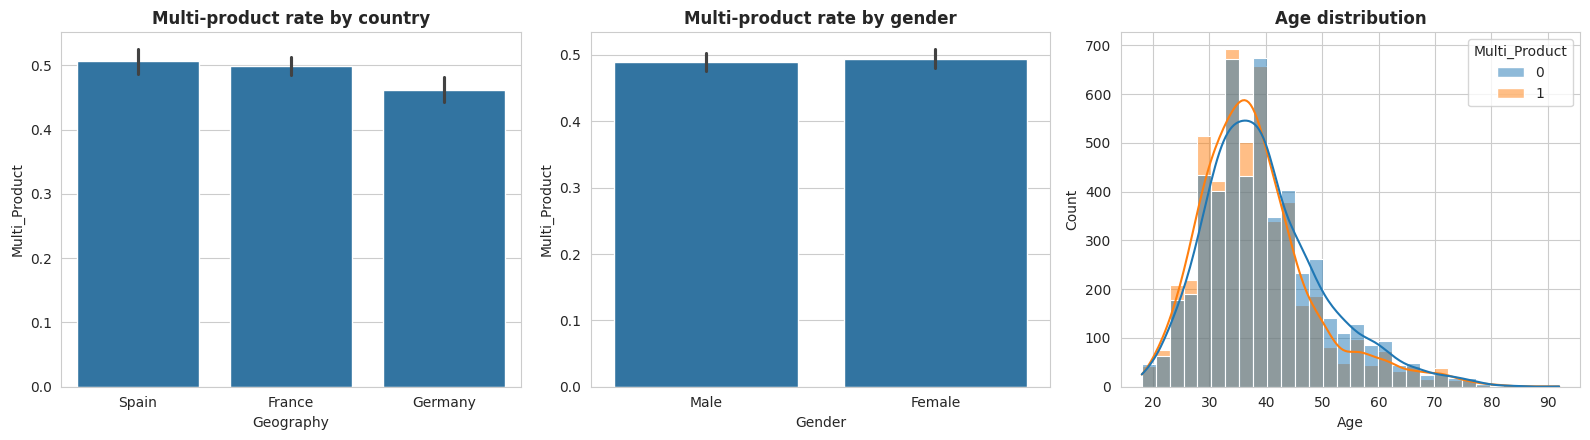

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(x="Geography", y="Multi_Product", data=df, ax=ax[0]); ax[0].set_title("Multi-product rate by country",fontweight='bold')
sns.barplot(x="Gender", y="Multi_Product", data=df, ax=ax[1]);    ax[1].set_title("Multi-product rate by gender",fontweight='bold')
sns.histplot(data=df, x="Age", hue="Multi_Product", bins=30, kde=True, ax=ax[2]); ax[2].set_title("Age distribution",fontweight='bold')
plt.tight_layout(); plt.show()

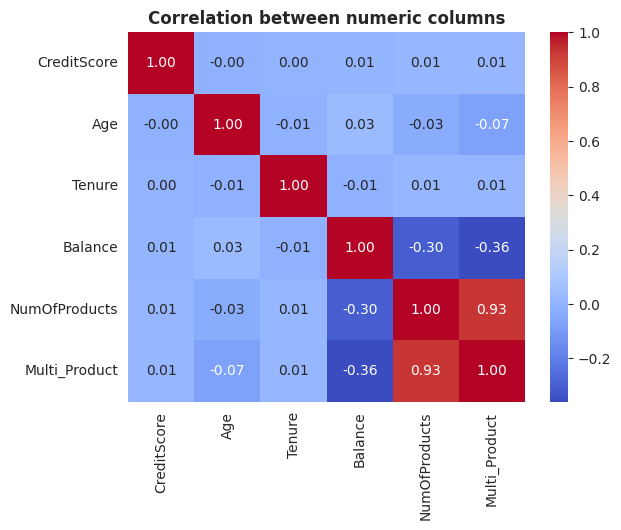

In [6]:
sns.heatmap(df[["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "Multi_Product"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between numeric columns",fontweight='bold'); plt.show()

## **4️⃣ Prepare the data**
- We drop ID-style columns (`RowNumber`, `CustomerId`, `Surname`) because they carry no real signal.
- ⚠️ We also drop `NumOfProducts` itself, because the target is built from it (**data leakage**).

In [7]:
X = df.drop(columns=["RowNumber", "CustomerId", "Surname", "NumOfProducts", "Multi_Product"])
y = df["Multi_Product"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print("Categorical:", cat_cols); print("Numeric:", num_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

Categorical: ['Geography', 'Gender']
Numeric: ['CreditScore', 'Age', 'Tenure', 'Balance']
Train: (8000, 6)  Test: (2000, 6)


## **5️⃣ Train multiple models (baseline → best**)
| Model | Why we use it |
|---|---|
| Dummy | Baseline: always predicts the most common class |
| Logistic Regression | Simple, fast, easy to explain |
| Decision Tree | Easy rules, but can overfit |
| Random Forest | Many trees voting together |
| Gradient Boosting | Trees that learn from earlier mistakes |

In [8]:
models = {
    "Dummy (baseline)":    DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred, proba = pipe.predict(X_test), pipe.predict_proba(X_test)[:, 1]
    results.append({"Model": name,
                    "Accuracy":  accuracy_score(y_test, pred),
                    "Precision": precision_score(y_test, pred, zero_division=0),
                    "Recall":    recall_score(y_test, pred),
                    "F1":        f1_score(y_test, pred),
                    "ROC-AUC":   roc_auc_score(y_test, proba)})

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.6940,0.7238,0.6104,0.6623,0.7368
1,Random Forest,0.6915,0.7080,0.6338,0.6688,0.7336
2,Logistic Regression,0.6865,0.6978,0.6389,0.6670,0.7249
3,Gradient Boosting,0.6855,0.7011,0.6277,0.6624,0.7249
4,Dummy (baseline),0.5085,0.0000,0.0000,0.0000,0.5000


## **6️⃣ Compare the models**
A good model must clearly beat the **Dummy baseline**. We rank by ROC-AUC (works even if classes are uneven).

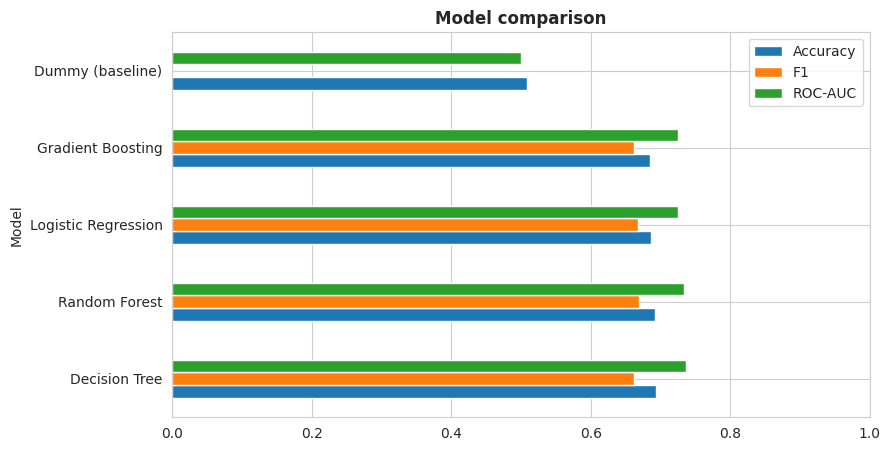

In [9]:
results_df.set_index("Model")[["Accuracy", "F1", "ROC-AUC"]].plot(kind="barh", figsize=(9, 5))
plt.title("Model comparison",fontweight='bold'); plt.xlim(0, 1); plt.show()

## **7️⃣ Tune the best model**
We try a small grid of Gradient Boosting settings with 3-fold cross-validation.

In [10]:
pipe = Pipeline([("prep", preprocess),
                 ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])
param_grid = {"model__learning_rate": [0.03, 0.05, 0.1],
              "model__max_depth": [3, 4, 6],
              "model__max_iter": [100, 200],
              "model__min_samples_leaf": [20, 50]}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best settings:", grid.best_params_)
print("Best CV ROC-AUC: {:.4f}".format(grid.best_score_))
best_model = grid.best_estimator_

Best settings: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_iter': 100, 'model__min_samples_leaf': 50}
Best CV ROC-AUC: 0.7365


## **8️⃣ Final evaluation on the unseen test set**

{'Accuracy': 0.6935, 'Precision': 0.7295, 'Recall': 0.5982, 'F1': 0.6574, 'ROC-AUC': np.float64(0.7479)}

               precision    recall  f1-score   support

  One product       0.67      0.79      0.72      1017
Multi-product       0.73      0.60      0.66       983

     accuracy                           0.69      2000
    macro avg       0.70      0.69      0.69      2000
 weighted avg       0.70      0.69      0.69      2000



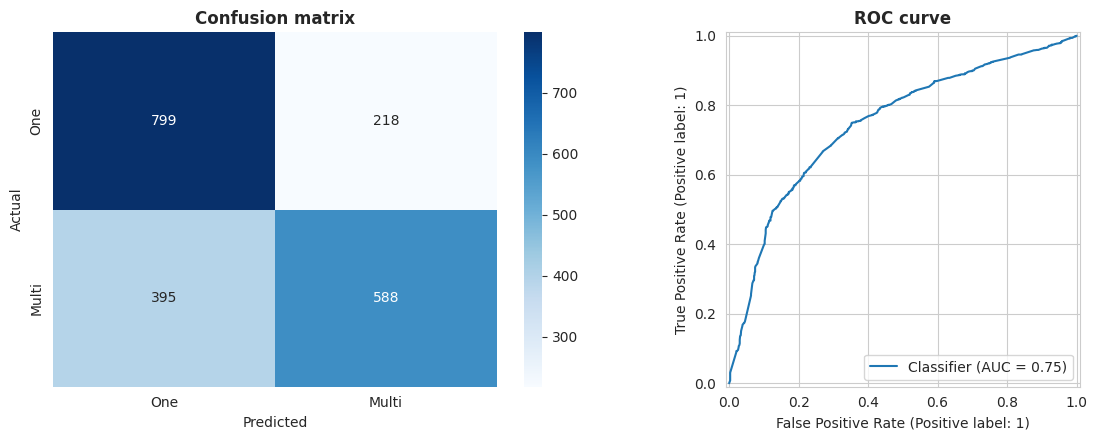

In [11]:
pred, proba = best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1]
final = {"Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
         "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, proba)}
print({k: round(v, 4) for k, v in final.items()}); print()
print(classification_report(y_test, pred, target_names=["One product", "Multi-product"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["One", "Multi"], yticklabels=["One", "Multi"])
ax[0].set_title("Confusion matrix",fontweight='bold'); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1]); ax[1].set_title("ROC curve",fontweight='bold')
plt.tight_layout(); plt.show()

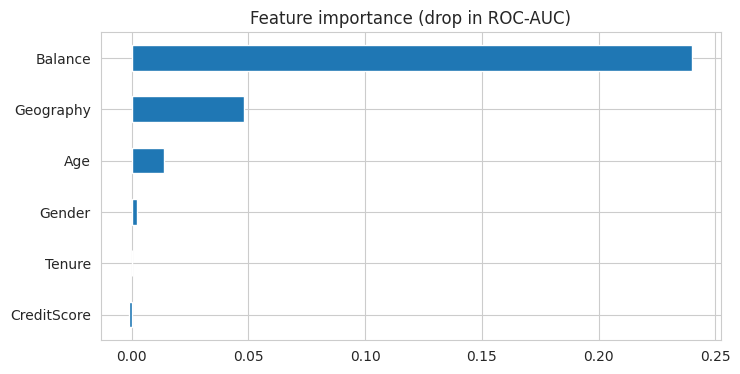

In [13]:
imp = permutation_importance(best_model, X_test, y_test, scoring="roc_auc",
                             n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
pd.Series(imp.importances_mean, index=X_test.columns).sort_values().plot(
    kind="barh", figsize=(8, 4), title="Feature importance (drop in ROC-AUC)")
plt.show()

## **9️⃣ Conclusion**
**Results on the 2,000-row test set**

| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| Dummy (baseline) | 0.509 | 0.000 | 0.500 |
| Logistic Regression | 0.687 | 0.667 | 0.725 |
| Gradient Boosting | 0.686 | 0.662 | 0.725 |
| Random Forest | 0.692 | 0.669 | 0.734 |
| Decision Tree | 0.694 | 0.662 | 0.737 |
| **Tuned Gradient Boosting** | **0.694** | **0.657** | **0.748** |

- **Every model beats the baseline by about 18 points** (0.51 → ~0.69 accuracy). The tuned Gradient Boosting model has the best ROC-AUC (0.748).
- Models score close together. This tells us the profile columns carry only **limited signal** for this target, so ~69% is a realistic ceiling here. Extra features (zero-balance flag, age squared, balance/age) did not improve it in our checks.
- **Biggest pattern:** customers with a **zero balance** are far more often multi-product (about 75% vs 35% for customers with a balance). Younger customers (under 40) are also more often multi-product.
- Gender, credit score and tenure matter little.
- **Business tip:** use the model to rank customers for cross-sell offers (ROC-AUC 0.75), not as a precise yes/no decision.
- **Next steps:** the full Kaggle file has more columns (`IsActiveMember`, `EstimatedSalary`, `Satisfaction Score`, `Card Type`, `Exited`). Adding them, or predicting churn directly, would likely give richer results.